In [ ]:
# Install / verify required packages
!pip install -q opencv-python-headless scikit-learn matplotlib seaborn tensorflow

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

from google.colab import drive
from PIL import Image
import json, time

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'OpenCV version     : {cv2.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.19.0
OpenCV version     : 4.13.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


# ─── EDIT THIS PATH to your dataset folder ───────────────────────────────────
DATA_ROOT = '/content/drive/MyDrive/AITool'
# ─────────────────────────────────────────────────────────────────────────────
import os
# Auto-detect class folders
CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
NUM_CLASSES = len(CLASS_NAMES)
CLASS_INDEX = {name: i for i, name in enumerate(CLASS_NAMES)}

print(f'Found {NUM_CLASSES} classes: {CLASS_NAMES}')
for cls in CLASS_NAMES:
    count = len(os.listdir(os.path.join(DATA_ROOT, cls)))
    print(f'  {cls:25s} → {count} images')

Found 3 classes: ['Deficiency', 'Normal', 'Rashes']
  Deficiency                → 29 images
  Normal                    → 14 images
  Rashes                    → 86 images


In [ ]:

IMG_SIZE      = 128          # Input image size (128×128)
BATCH_SIZE    = 16           # Batch size for training
EPOCHS        = 60           # Max epochs (EarlyStopping will halt earlier)
LEARNING_RATE = 1e-3         # Initial learning rate
VAL_SPLIT     = 0.15         # 15% validation
TEST_SPLIT    = 0.15         # 15% test
DROPOUT_RATE  = 0.4          # Dropout regularisation
L2_REG        = 1e-4         # L2 weight decay


MODEL_SAVE_PATH = '/content/drive/MyDrive/zinc_cnn_scratch.keras'
print('Config set.')

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from google.colab import drive

drive.mount('/content/drive')

DATA_ROOT  = '/content/drive/MyDrive/AITool'
IMG_SIZE   = 128
BATCH_SIZE = 16
SEED       = 42


CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
NUM_CLASSES = len(CLASS_NAMES)
CLASS_INDEX = {name: i for i, name in enumerate(CLASS_NAMES)}
print('Classes:', CLASS_NAMES)

# ── Load dataset ──────────────────────────────────────
SUPPORTED_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')

def load_dataset(data_root, img_size, class_index):
    images, labels, paths = [], [], []
    for class_name, label in class_index.items():
        folder = os.path.join(data_root, class_name)
        files  = [f for f in os.listdir(folder)
                  if f.lower().endswith(SUPPORTED_EXTS)]
        print(f'  Loading {len(files):4d} images from [{class_name}]...')
        for fname in files:
            fpath = os.path.join(folder, fname)
            try:
                img = cv2.imread(fpath)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_size, img_size))
                images.append(img)
                labels.append(label)
                paths.append(fpath)
            except Exception as e:
                print(f'    ⚠ Skipping {fname}: {e}')
    return np.array(images, dtype=np.float32) / 255.0, np.array(labels), paths

print('\nLoading dataset...')
X, y, img_paths = load_dataset(DATA_ROOT, IMG_SIZE, CLASS_INDEX)
y_cat = to_categorical(y, NUM_CLASSES)

print(f'\nDataset summary:')
print(f'  Total images : {len(X)}')
print(f'  Image shape  : {X.shape[1:]}')
print(f'  Classes      : {NUM_CLASSES}')
for cls, idx in CLASS_INDEX.items():
    print(f'  {cls:25s}: {np.sum(y == idx)} samples')

Mounted at /content/drive
Classes: ['Deficiency', 'Normal', 'Rashes']

Loading dataset...
  Loading   22 images from [Deficiency]...
  Loading   13 images from [Normal]...
  Loading   86 images from [Rashes]...

Dataset summary:
  Total images : 121
  Image shape  : (128, 128, 3)
  Classes      : 3
  Deficiency               : 22 samples
  Normal                   : 13 samples
  Rashes                   : 86 samples


In [ ]:
from tensorflow.keras.utils import to_categorical

y_cat = to_categorical(y, NUM_CLASSES)

print("\nOne-hot label shape:", y_cat.shape)


One-hot label shape: (121, 3)


In [ ]:
print("\n Dataset Summary")

for cls, idx in CLASS_INDEX.items():
    count = np.sum(y == idx)
    print(f"{cls:25s}: {count} samples")

print("\nTotal Images:", len(X))


 Dataset Summary
Deficiency               : 22 samples
Normal                   : 13 samples
Rashes                   : 86 samples

Total Images: 121


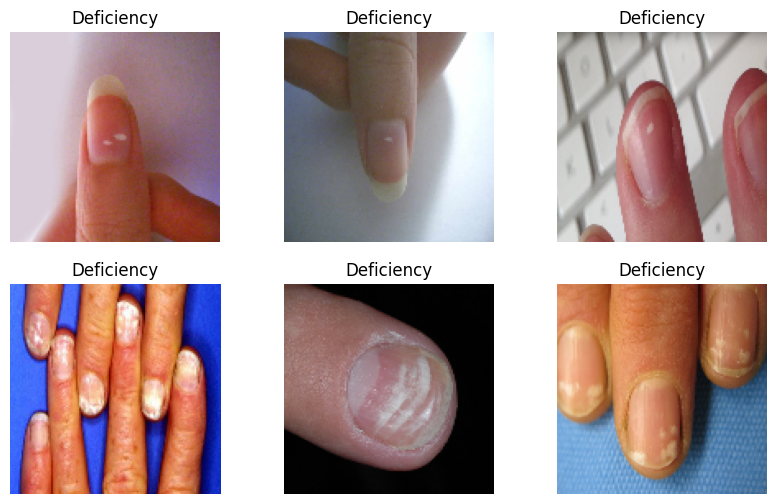

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i in range(min(6, len(X))):
    plt.subplot(2,3,i+1)
    plt.imshow(X[i])
    plt.title(CLASS_NAMES[y[i]])
    plt.axis("off")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# First split (Train + Temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.3, random_state=42, stratify=y
)

# Second split (Validation + Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (84, 128, 128, 3)
Val: (18, 128, 128, 3)
Test: (19, 128, 128, 3)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 16
SEED = 42

train_aug = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.75, 1.30],
    fill_mode='reflect'
)

val_aug = ImageDataGenerator()

train_gen = train_aug.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_gen   = val_aug.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

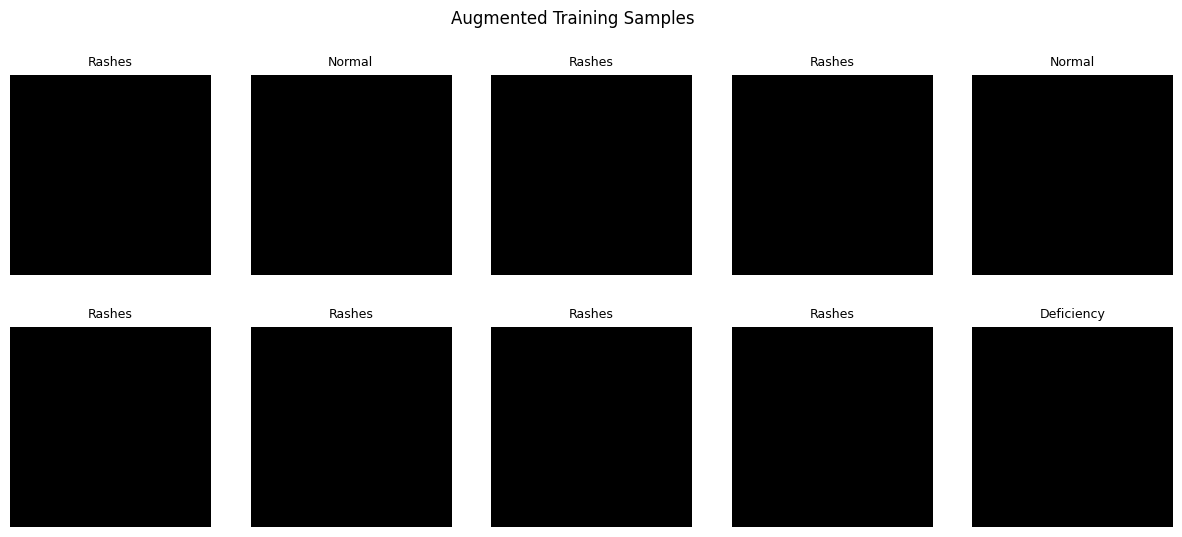

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
batch_imgs, batch_labels = next(train_gen)

for i, ax in enumerate(axes.flat):
    if i < len(batch_imgs):
        ax.imshow(batch_imgs[i])
        cls = CLASS_NAMES[np.argmax(batch_labels[i])]
        ax.set_title(cls, fontsize=9)
    ax.axis('off')

plt.suptitle('Augmented Training Samples')
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,923 (12.61 MB)

 Trainable params: 3,305,475 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6190 - loss: 2.1843 - val_accuracy: 0.0556 - val_loss: 2.6338 - learning_rate: 0.0010
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.4881 - loss: 2.7662 - val_accuracy: 0.1667 - val_loss: 2.6477 - learning_rate: 0.0010
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7381 - loss: 7.1402 - val_accuracy: 0.2222 - val_loss: 3.2956 - learning_rate: 0.0010
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7500 - loss: 9.7015 - val_accuracy: 0.2222 - val_loss: 14.5854 - learning_rate: 0.0010
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7262 - loss: 1.6928 - val_accuracy: 0.2222 - val_loss: 18.4825 - learning_rate: 3.0000e-04
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.7262 - loss: 6.6276 - val_accuracy: 0.2778 - val_loss: 20.2985 - learning_rate: 3.0000e-04


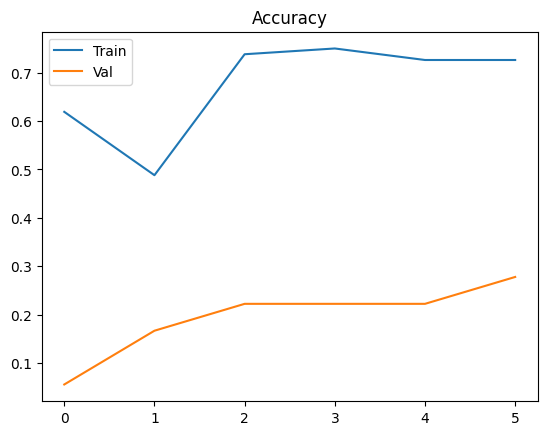

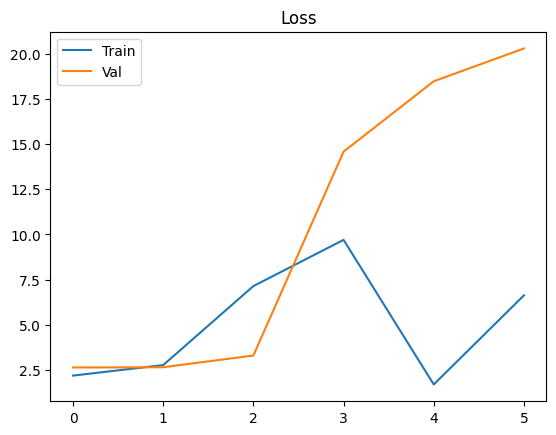

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Val"])
plt.show()

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1053 - loss: 2.8046
Test Accuracy: 10.526315867900848


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step
              precision    recall  f1-score   support

  Deficiency       0.00      0.00      0.00         3
      Normal       0.11      0.67      0.19         3
      Rashes       0.00      0.00      0.00        13

    accuracy                           0.11        19
   macro avg       0.04      0.22      0.06        19
weighted avg       0.02      0.11      0.03        19

Confusion Matrix:
 [[ 0  3  0]
 [ 1  2  0]
 [ 0 13  0]]


In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc*100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.1053 - loss: 2.8046
Test Accuracy: 10.526315867900848


In [ ]:
def detect_edges_canny(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    return edges, edges

In [ ]:
def detect_white_spots_leukonychia(img):

    import cv2
    import numpy as np

    output = img.copy()

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    # Skin mask
    lower_skin = np.array([0, 20, 70])
    upper_skin = np.array([25, 255, 255])
    skin_mask = cv2.inRange(hsv, lower_skin, upper_skin)

    kernel = np.ones((5,5), np.uint8)
    skin_mask = cv2.morphologyEx(skin_mask, cv2.MORPH_CLOSE, kernel)

    skin_only = cv2.bitwise_and(img, img, mask=skin_mask)

    gray = cv2.cvtColor(skin_only, cv2.COLOR_RGB2GRAY)

    #  Detect bright regions (lower threshold)
    _, thresh = cv2.threshold(gray, 190, 255, cv2.THRESH_BINARY)

    thresh = cv2.medianBlur(thresh, 5)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    valid_cnts = []
    h, w = gray.shape

    for cnt in contours:

        area = cv2.contourArea(cnt)

        #  ALLOW LINES (bigger area now)
        if area < 20 or area > 1000:
            continue

        x, y, cw, ch = cv2.boundingRect(cnt)

        # Remove borders
        if x < 5 or y < 5 or x+cw > w-5 or y+ch > h-5:
            continue

        #  LINE DETECTION (IMPORTANT)
        aspect_ratio = cw / (ch + 1e-5)

        # allow elongated shapes (lines)
        if aspect_ratio > 2 or aspect_ratio < 0.5:
            cv2.drawContours(output, [cnt], -1, (255,0,0), 2)
            valid_cnts.append(cnt)

    return thresh, output, valid_cnts

In [ ]:
def detect_ringworm_edges(img):

    import cv2
    import numpy as np

    output = img.copy()

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Step 1: Edge detection (VERY IMPORTANT)
    edges = cv2.Canny(gray, 80, 150)

    # Step 2: Close gaps in edges
    kernel = np.ones((3,3), np.uint8)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # Step 3: Find contours
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    valid = []

    for cnt in contours:

        area = cv2.contourArea(cnt)

        # Ignore very small noise
        if area < 200:
            continue

        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue

        circularity = 4 * np.pi * (area / (perimeter * perimeter))


        if 0.3 < circularity < 0.85:


            (x, y), r = cv2.minEnclosingCircle(cnt)

            if r > 20:
                cv2.circle(output, (int(x), int(y)), int(r), (255, 0, 0), 3)
                valid.append(cnt)

    return output, valid

In [ ]:
def compute_texture_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    bright_pct = np.sum(gray > 200) / gray.size * 100

    return {
        "laplacian_variance": round(lap_var, 2),
        "bright_pixel_pct": round(bright_pct, 2)
    }

In [ ]:
def analyze_image(file, model, class_names, img_size=128):

    import cv2, numpy as np, matplotlib.pyplot as plt

    file_bytes = np.frombuffer(file, np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None:
        print(" Error loading image")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_small = cv2.resize(img_rgb, (img_size, img_size))

    # ── Prediction ──
    inp = img_small / 255.0
    inp = np.expand_dims(inp, axis=0)

    probs = model.predict(inp, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = class_names[pred_idx]
    confidence = probs[pred_idx]

    print(f"\n Model Prediction: {pred_class} ({confidence*100:.1f}%)")

    # ── Image Processing ──
    mask, annotated_w, contours = detect_white_spots_leukonychia(img_small)
    annotated_ring, ring_cnts = detect_ringworm_edges(img_small)

    # ── Decision Logic ──
    if confidence >= 0.75:

        if pred_class.lower() in ["anaemia", "leukonychia"]:
            final_img = annotated_w
            label = f"White Lines on Nail: {len(contours)}"

        elif pred_class.lower() in ["skin_infection", "ringworm"]:
            final_img = annotated_ring
            label = f"Ringworm ({len(ring_cnts)} region)"

        else:
            final_img = img_small
            label = "Healthy"

    else:
        print(" Low confidence → using fallback")

        if len(contours) >= 1 and len(ring_cnts) == 0:
            final_img = annotated_w
            label = f"White Lines Detected: {len(contours)}"

        elif len(ring_cnts) > 0:
            final_img = annotated_ring
            label = f"Ringworm Detected ({len(ring_cnts)} region)"

        else:
            final_img = img_small
            label = "Likely Healthy"

    # ── Display ──
    plt.imshow(final_img)
    plt.title(f"{label}\nConfidence: {confidence*100:.1f}%")
    plt.axis("off")
    plt.show()

Saving 1_58.jpg to 1_58.jpg

🧠 Model Prediction: Normal (60.9%)
⚠ Low confidence → using fallback


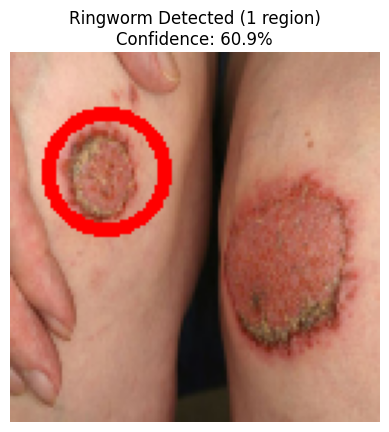

In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    analyze_image(uploaded[filename], model, CLASS_NAMES)

Saving 1_60.jpg to 1_60.jpg

🧠 Model Prediction: Normal (55.1%)
⚠ Low confidence → using fallback


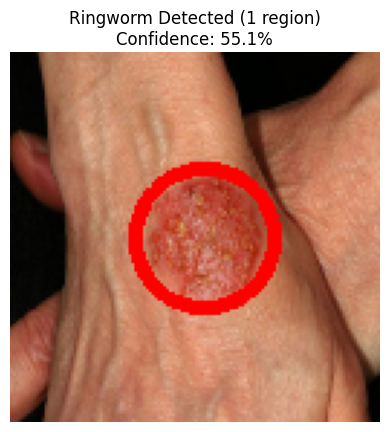

In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    analyze_image(uploaded[filename], model, CLASS_NAMES)


🧠 Model Prediction: Deficiency (65.4%)
⚠ Low confidence → using image processing fallback


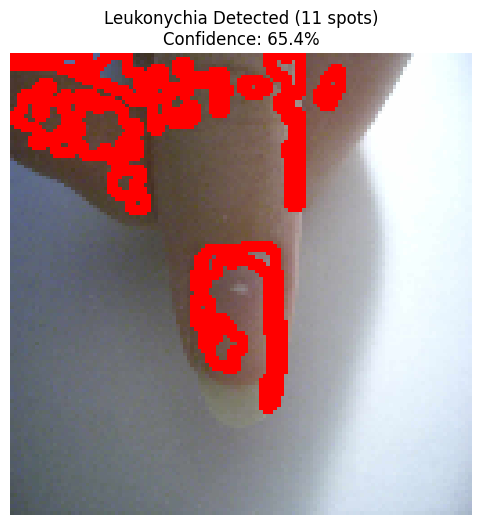


FINAL RESULT
Prediction: Deficiency
Confidence: 65.4 %
White spots: 11
Infection regions: 2


In [ ]:
for file in uploaded.keys():
    analyze_image(file, model, CLASS_NAMES)

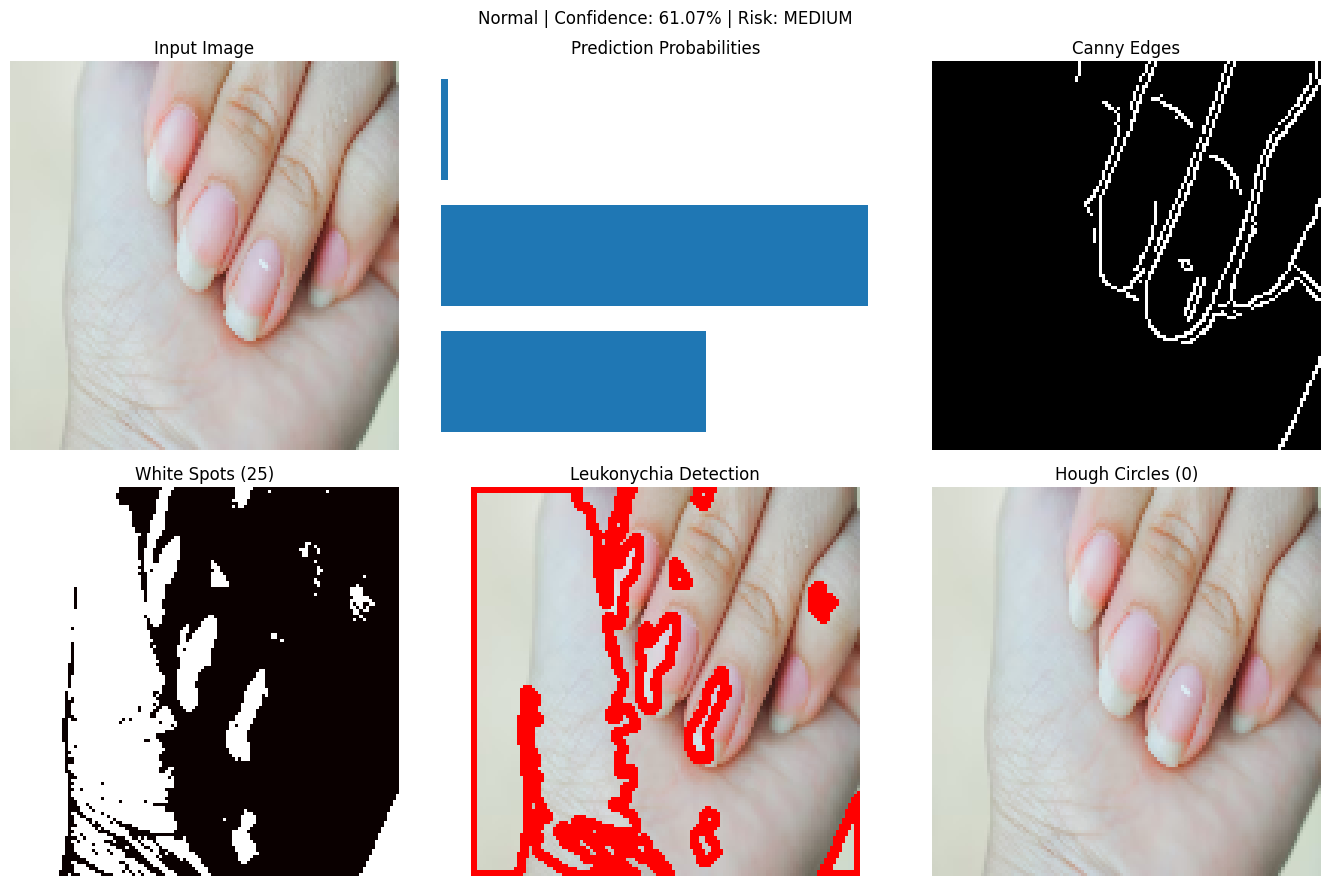


🧾 DIAGNOSTIC REPORT
File: white-spots-finger-nails-called-leukonychia-reveal-emergence-health-problems_454892-582.avif
Prediction: Normal
Confidence: 61.07 %
Risk Level: MEDIUM
White Spots: 25
Circles Detected: 0
Texture: {'laplacian_variance': np.float64(420.16), 'bright_pixel_pct': np.float64(42.06)}
--------------------------------------------------
Advice: ⚠ General checkup advised


In [ ]:
for file in uploaded.keys():
    analyze_image(file, model, CLASS_NAMES)